<a href="https://colab.research.google.com/github/Shinevenbrighter/Implementacion-de-Tries/blob/main/Actividad_3_1_Implementaci%C3%B3n_de_%22Tries%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tecnológico de Monterrey Campus Toluca

Actividad 3.1 Implementación de Patrones Regex

Alumna: Valentina Tejeda Fuentes A01771768

Materia: Análisis y diseño de algoritmos avanzados

Grupo: 601

Profesor: Marcial Roberto Leyva Fernandez

##Introducción

Un Trie también llamado árbil de prefijos es una estructura de datos en forma de árbol usada para almacenar conjuntos de cadenas.

Cada nodo va a representar un carácter y una ruta desde la raíz representa una palabra completa o parcial.
(Correa, 2025)

En este proyecto, se construyó un trie que contiene palabras como casa, caso, corto, casta, calma y caro.

A partir de una matriz de adyacencia y un diccionario que asocia nodos a letras, se implementó un algoritmo de búsqueda en profundidad (DFS) que permite encontrar la ruta exacta de cada palabra dentro del grafo.

A continuación se presenta el grafo utilizado:

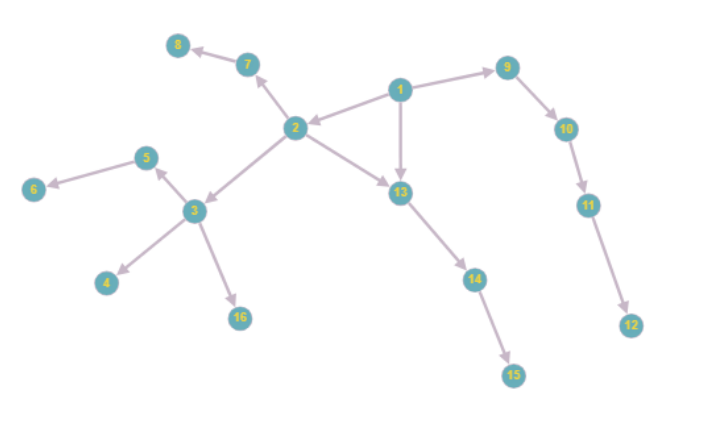

*Imagen 1. Gráfo de 16 nodos*

In [ ]:
%%writefile tries.py
# -------------------------------
# NODOS Y MATRIZ DE ADYACENCIA
# -------------------------------
nodos = {
    1: 'C',
    2: 'A',
    3: 'S',
    4: 'A',
    5: 'T',
    6: 'A',
    7: 'R',
    8: 'O',
    9: 'O',
    10: 'R',
    11: 'T',
    12: 'O',
    13: 'L',
    14: 'M',
    15: 'A',
    16: 'O'
}

matriz = [
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0], # 1
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0], # 2
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], # 3
    [0]*16, # 4
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0], # 5
    [0]*16, # 6
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0], # 7
    [0]*16, # 8
    [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0], # 9
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0], # 10
    [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0], # 11
    [0]*16, # 12
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0], # 13
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0], # 14
    [0]*16, # 15
    [0]*16, # 16
]

# -------------------------------
# FUNCION DE BÚSQUEDA DFS
# -------------------------------
def buscar_ruta(palabra):
    palabra = palabra.upper()
    rutas = []

    def dfs(nodo, ruta, restante):
        if not restante:
            rutas.append(ruta[:])
            return
        for i, conectado in enumerate(matriz[nodo-1]):
            if conectado and nodos.get(i+1) == restante[0]:
                dfs(i+1, ruta + [i+1], restante[1:])

    for nodo, letra in nodos.items():
        if letra == palabra[0]:
            dfs(nodo, [nodo], palabra[1:])

    return rutas

# -------------------------------
# PROGRAMA PRINCIPAL - REPITE 6 VECES
# -------------------------------
for _ in range(8):
    nombre = input("Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): ").lower()
    rutas = buscar_ruta(nombre)

    if rutas:
        for ruta in rutas:
            print(f"Ruta encontrada: {ruta} -> {''.join(nodos[n] for n in ruta)}\n")
    else:
        print("No se encontró la palabra en el grafo.")


Overwriting tries.py


In [ ]:
!python tries.py

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): casa
Ruta encontrada: [1, 2, 3, 4] -> CASA

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): caso
Ruta encontrada: [1, 2, 3, 16] -> CASO

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): corto
Ruta encontrada: [1, 9, 10, 11, 12] -> CORTO

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): casta
Ruta encontrada: [1, 2, 3, 5, 6] -> CASTA

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): calma
Ruta encontrada: [1, 2, 13, 14, 15] -> CALMA

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): caro
Ruta encontrada: [1, 2, 7, 8] -> CARO

Ingresa la palabra a buscar (Palabras en el gráfo: Casa, caso, corto, casta, calma, caro): camo
No se encontró la palabra en el grafo.
Ingresa la palabra a buscar (Pala

##Resultados

| Palabra | Ruta de nodos      | Secuencia de letras | Resultado |
| ------- | ------------------ | ------------------- | --------- |
| casa    | [1, 2, 3, 4]       | C-A-S-A             | Exitoso   |
| caso    | [1, 2, 3, 16]      | C-A-S-O             | Exitoso   |
| corto   | [1, 9, 10, 11, 12] | C-O-R-T-O           | Exitoso   |
| casta   | [1, 2, 3, 5, 6]    | C-A-S-T-A           | Exitoso   |
| calma   | [1, 2, 13, 14, 15] | C-A-L-M-A           | Exitoso   |
| caro    | [1, 2, 7, 8]       | C-A-R-O             | Exitoso   |
| camo    | No se encontró la palabra en el grafo       | C-A-R-O             | Exitoso   |
| cas    | [1, 2, 3]       | C-A-R-O             | Exitoso   |



##Conclusión

El proyecto permitió comprender la estructura y funcionamiento de trie, así como su implementación durante la generación de un grafó con palabras relacionadas entre si que empezaran con "c". La matriz de adyacencia y el diccionario de nodos facilitan la representación del trie, mientras que el algoritmo permitió encontrar rutas exactas para palabras ingresadas por el usuario.
Además señala cuando no existe una palabra dentro del grafo, necesitaríamos crear nuevas ramas, para que este se muestre, lo que demuestra que la busqueda la hace manera correcta.

Se comprueba que el trie es eficiente para almacenar palabras con prefijos compartidos y realizar búsquedas rápidas, lo que lo hace útil en aplicaciones de procesamiento de texto y motores de búsqueda.



##Referencias

Correa, J. (2025, May 4). Trie. DSAListo. https://www.dsalisto.com/estructuras-de-datos/trie

‌